准确率: 0.975
召回率: 0.9743589743589745
F1 分数: 0.9740084388185654
混淆矩阵:
[[43  0  0]
 [ 0 36  3]
 [ 0  0 38]]


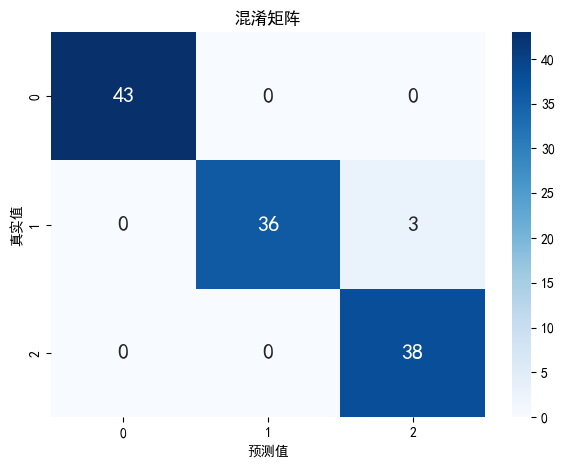

In [11]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print(f"准确率: {accuracy}")
print(f"召回率: {recall}")
print(f"F1 分数: {f1}")
print(f"混淆矩阵:\n{cm}")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues', annot_kws={"size": 16})

plt.ylabel('真实值')
plt.xlabel('预测值')
plt.title('混淆矩阵')

plt.show()

训练集类别: {'misc.forsale', 'rec.autos', 'talk.politics.guns', 'comp.os.ms-windows.misc', 'rec.sport.hockey', 'talk.politics.misc', 'sci.space', 'comp.graphics', 'rec.motorcycles', 'comp.sys.mac.hardware', 'talk.religion.misc', 'alt.atheism', 'sci.med', 'comp.sys.ibm.pc.hardware', 'sci.crypt', 'talk.politics.mideast', 'comp.windows.x', 'rec.sport.baseball', 'sci.electronics', 'soc.religion.christian'}
训练样本数量: 11314

示例文档:
 From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Atheist Resources
Summary: Books, addresses, music -- anything related to atheism
Keywords: FAQ, atheism, books, music, fiction, addresses, contacts
Expires: Thu, 29 Apr 1993 11:57:19 GMT
Distribution: world
Organization: Mantis Consultants, Cambridge. UK.
Supersedes: <19930301143317@mantis.co.uk>
Lines: 290

Archive-name: atheism/resources
Alt-atheism-archive-name: resources
Last-modified: 11 December 1992
Version: 1.0

              
准确率: 0.7728359001593202
召回率: 0.7636463041415988
F1 分数: 0.7450982330052153
混淆

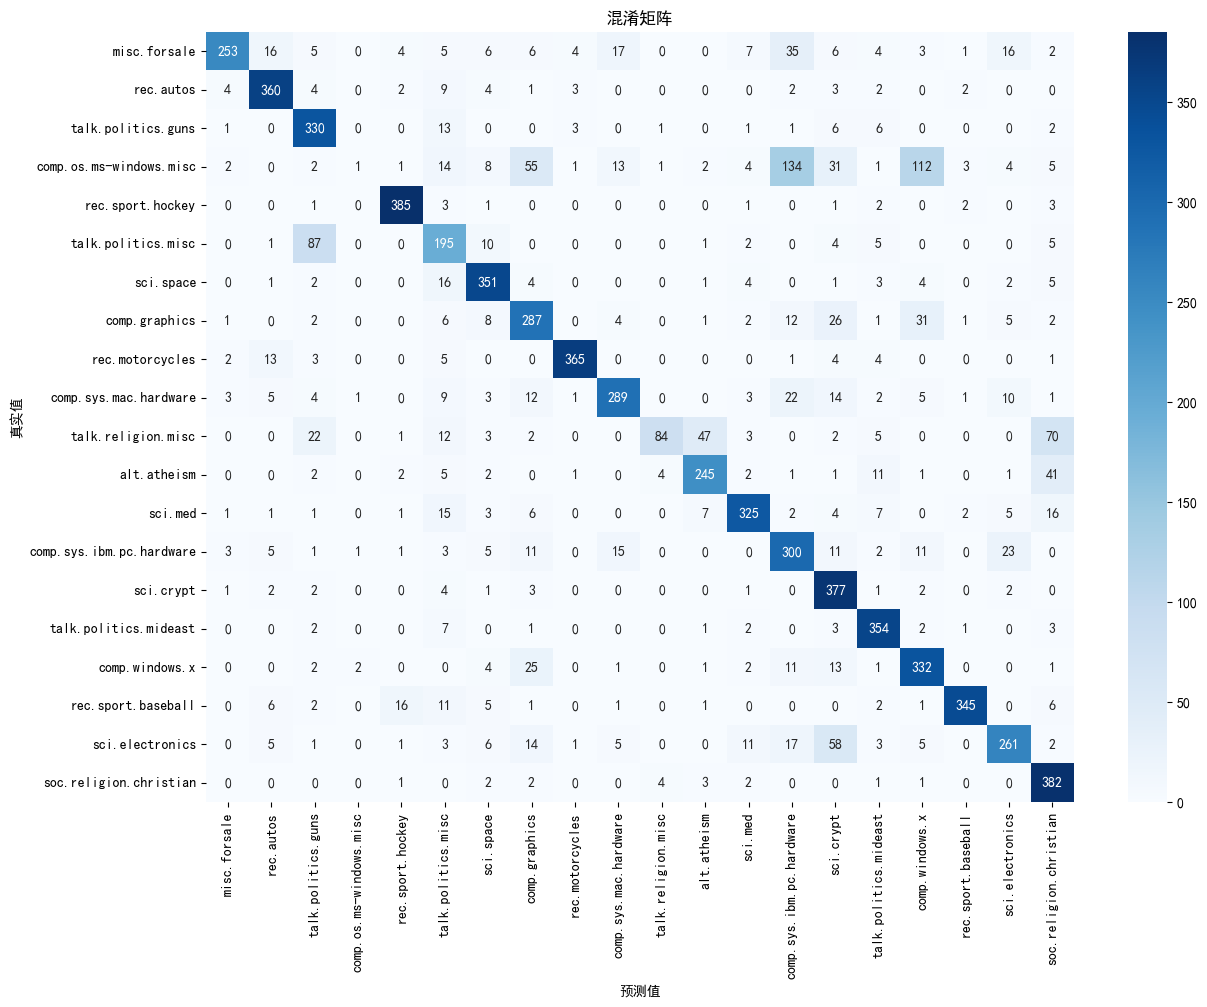

类别 'alt.atheism': 310 条预测
类别 'talk.religion.misc': 94 条预测
类别 'talk.politics.mideast': 417 条预测
类别 'soc.religion.christian': 547 条预测
类别 'sci.electronics': 329 条预测
类别 'talk.politics.misc': 335 条预测
类别 'sci.med': 372 条预测
类别 'sci.crypt': 565 条预测
类别 'comp.windows.x': 510 条预测
类别 'talk.politics.guns': 475 条预测
类别 'rec.sport.hockey': 415 条预测
类别 'rec.motorcycles': 379 条预测
类别 'sci.space': 422 条预测
类别 'comp.sys.ibm.pc.hardware': 538 条预测
类别 'comp.graphics': 430 条预测
类别 'comp.sys.mac.hardware': 345 条预测
类别 'misc.forsale': 271 条预测
类别 'rec.sport.baseball': 358 条预测
类别 'comp.os.ms-windows.misc': 5 条预测
类别 'rec.autos': 415 条预测


In [10]:
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.font_manager import FontProperties

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def load_files_from_directory(directory):
    documents = []
    labels = []
    for category in os.listdir(directory):
        category_dir = os.path.join(directory, category)
        if os.path.isdir(category_dir):
            for filename in os.listdir(category_dir):
                file_path = os.path.join(category_dir, filename)
                with open(file_path, 'r', encoding='latin1') as file:
                    documents.append(file.read())
                    labels.append(category)
    return documents, labels

train_data_path = r'D:\常用软件\vscode\daolun\20news-bydate-train'
test_data_path = r'D:\常用软件\vscode\daolun\20news-bydate-test'

train_docs, train_labels = load_files_from_directory(train_data_path)
test_docs, test_labels = load_files_from_directory(test_data_path)

train_df = pd.DataFrame({'text': train_docs, 'label': train_labels})
test_df = pd.DataFrame({'text': test_docs, 'label': test_labels})

print("训练集类别:", set(train_labels))
print("训练样本数量:", len(train_docs))
print("\n示例文档:\n", train_docs[0][:500])

label_mapping = {label: idx for idx, label in enumerate(set(train_labels))}
y_train = [label_mapping[label] for label in train_labels]
y_test = [label_mapping[label] for label in test_labels]

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print(f"准确率: {accuracy}")
print(f"召回率: {recall}")
print(f"F1 分数: {f1}")
print(f"混淆矩阵:\n{cm}")

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys(),
            annot_kws={"size": 10})

plt.ylabel('真实值')
plt.xlabel('预测值')
plt.title('混淆矩阵')

plt.show()

predicted_counts = Counter(y_pred)
for label, count in predicted_counts.items():
    print(f"类别 '{list(label_mapping.keys())[label]}': {count} 条预测")

原始数据轮廓系数: 0.45994823920518635
PCA变换后数据轮廓系数: 0.5091683341538227


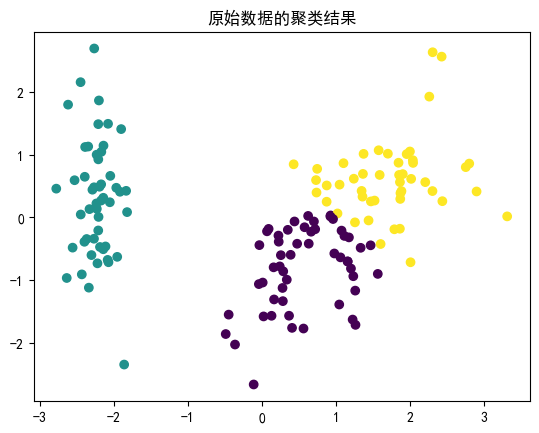

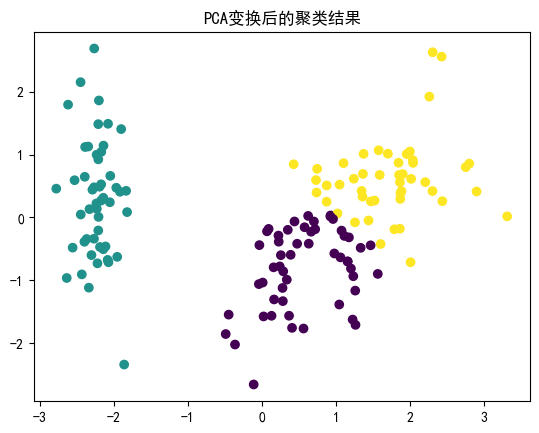

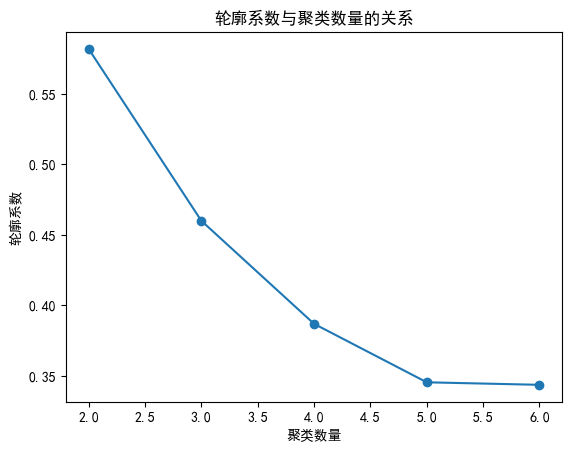

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=0).fit(X_scaled)

silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f"原始数据轮廓系数: {silhouette_avg}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=0).fit(X_pca)

silhouette_avg_pca = silhouette_score(X_pca, kmeans_pca.labels_)
print(f"PCA变换后数据轮廓系数: {silhouette_avg_pca}")

def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.title(title)
    plt.show()

plot_clusters(X_pca, kmeans.labels_, "原始数据的聚类结果")
plot_clusters(X_pca, kmeans_pca.labels_, "PCA变换后的聚类结果")

range_n_clusters = [2, 3, 4, 5, 6]
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = clusterer.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel("聚类数量")
plt.ylabel("轮廓系数")
plt.title("轮廓系数与聚类数量的关系")
plt.show()